# Iris Flower Classification Using Machine Learning

A Machine Learning project developed using Python and Scikit-learn to classify Iris flowers into different species based on their sepal and petal measurements. The project involves data preprocessing, exploratory data analysis, visualization, model training, and performance evaluation using classification algorithms such as Logistic Regression and Random Forest Classifier.

In [1]:
#IMPORTING LIBRARIES FOR DATA HANDLING
import pandas as pd
import numpy as np

In [2]:
#LOADING DATA
df = pd.read_csv('/content/IRIS.csv')

In [3]:
#DISPLAYING THE DATASET
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
#DISPLAYING INFORMATION ABOUT THE DATASET
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
#IDENTIFYING THE MISSING VALUE
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [6]:
#IMPORTING LIBRARIES FOR VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

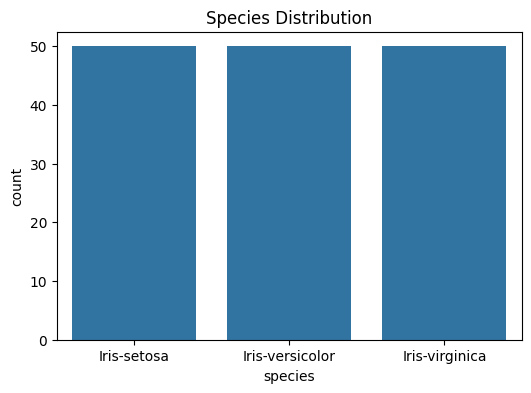

In [7]:
#SPECIES DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df)
plt.title("Species Distribution")
plt.show()

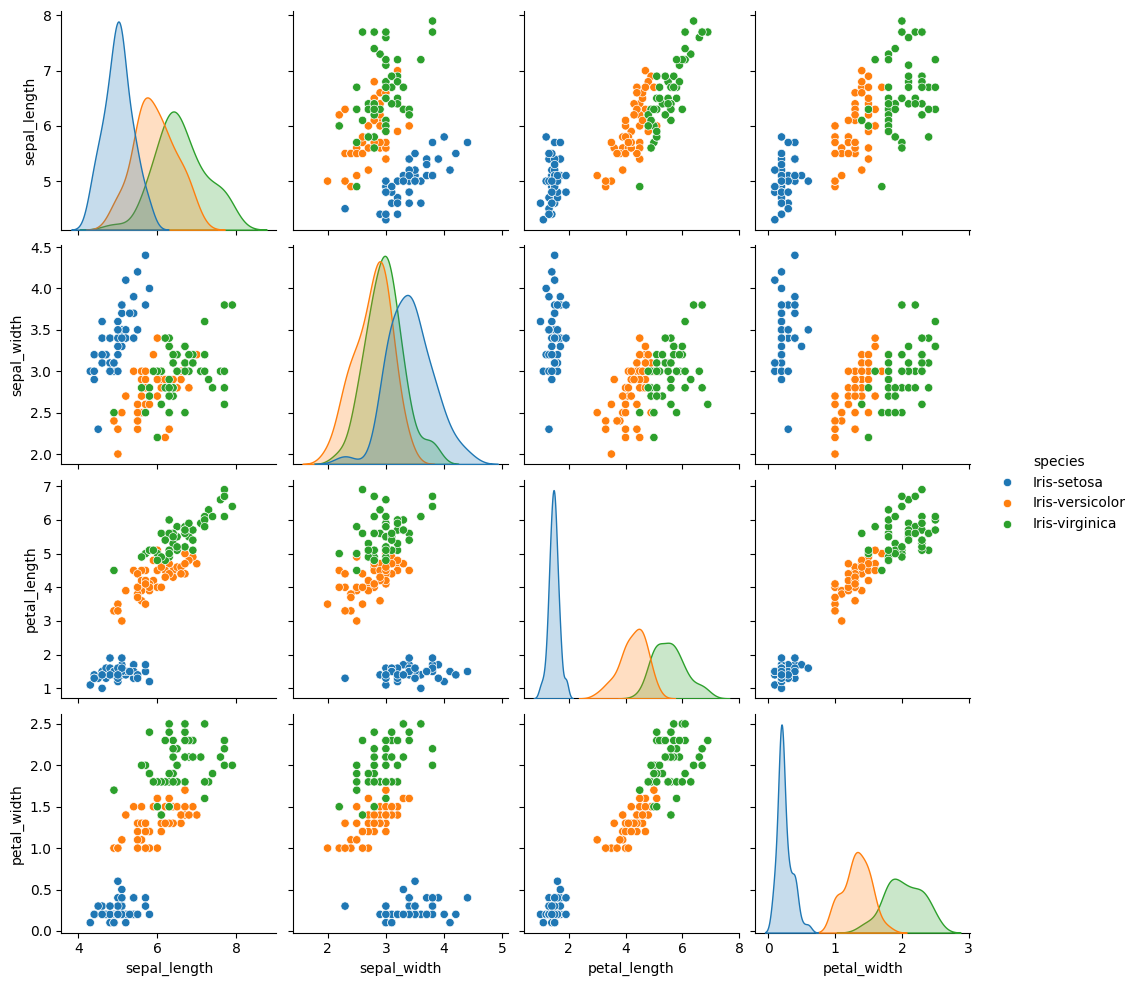

In [8]:
#PAIR PLOT
sns.pairplot(df, hue='species')
plt.show()

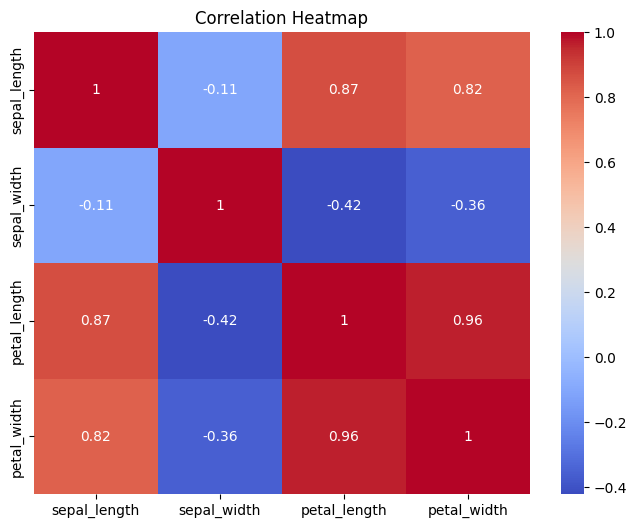

In [9]:
#CORRELATION HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(
    df.drop('species', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
#IMPORTING LIBRARIES FOR DATA PREPROCESSING
from sklearn.preprocessing import LabelEncoder

In [11]:
#LABEL ENCODING
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
#FEATURE SELECTION
X = df.drop('species', axis=1)
y = df['species']

In [13]:
#IMPORTING LIBRARIES FOR TEST TRAIN SPLIT
from sklearn.model_selection import train_test_split

In [14]:
#SPLIT DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
#IMPORTING LIBRARIES FOR MODEL TRAINING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [16]:
#LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [17]:
#RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [18]:
#IMPORTING LIBRARIES FOR MODEL EVALUATION
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [19]:
#ACCURACY
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_predictions))
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predictions))

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0


In [20]:
#CLASSIFICATION REPORT
print(classification_report(
    y_test,
    rf_predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



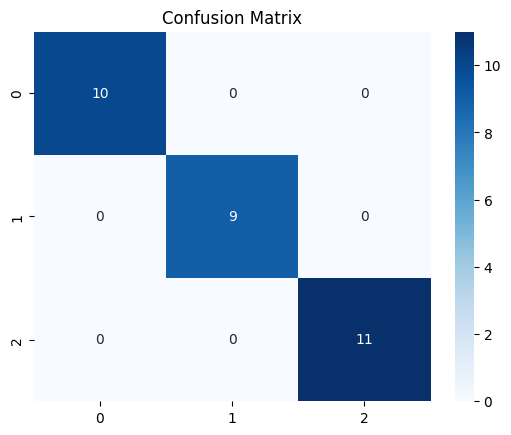

In [21]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    rf_predictions
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.show()

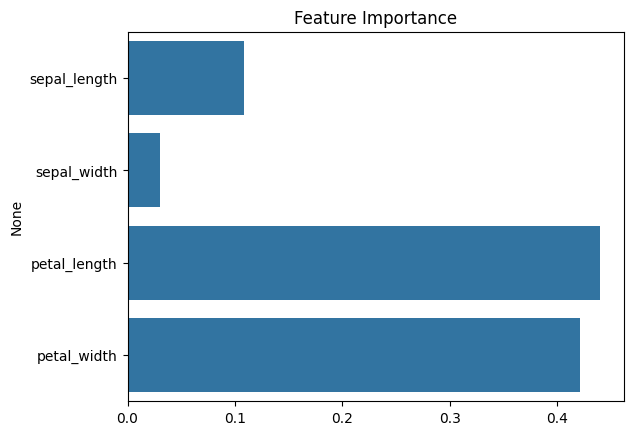

In [22]:
#FEATURE IMPORTANCE
importance = rf_model.feature_importances_
sns.barplot(
    x=importance,
    y=X.columns
)
plt.title("Feature Importance")
plt.show()

In [23]:
#PREDICT NEW FLOWER SPECIES
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = rf_model.predict(sample)
print(
    "Predicted Species:",
    encoder.inverse_transform(prediction)[0]
)

Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
